In [16]:
!pip install kagglehub

In [17]:
import kagglehub

path = kagglehub.dataset_download("rounakbanik/the-movies-dataset")

print("Dataset path:", path)

Using Colab cache for faster access to the 'the-movies-dataset' dataset.
Dataset path: /kaggle/input/the-movies-dataset


In [33]:
import pandas as pd
import os

movies = pd.read_csv(os.path.join(path, "movies_metadata.csv"), low_memory=False)

movies = movies[['title','genres','vote_average','popularity']]

movies.head()

,title,genres,vote_average,popularity
0,Toy Story,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",7.7,21.946943
1,Jumanji,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",6.9,17.015539
2,Grumpier Old Men,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",6.5,11.7129
3,Waiting to Exhale,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",6.1,3.859495
4,Father of the Bride Part II,"[{'id': 35, 'name': 'Comedy'}]",5.7,8.387519


In [39]:
movies['vote_average'] = pd.to_numeric(movies['vote_average'], errors='coerce')
movies['popularity'] = pd.to_numeric(movies['popularity'], errors='coerce')

movies = movies.dropna(subset=['vote_average','popularity'])
# Reset the index to ensure a continuous index after dropping rows, which is crucial for alignment
movies = movies.reset_index(drop=True)

import ast

def extract_genres(x):
    try:
        genres = ast.literal_eval(x)
        return [i['name'] for i in genres]
    except:
        return []

movies['genres'] = movies['genres'].apply(extract_genres)

movies.head()

In [40]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()

genre_encoded = pd.DataFrame(
    mlb.fit_transform(movies['genres']),
    columns=mlb.classes_
)

In [41]:
features = pd.concat([
    genre_encoded,
    movies[['vote_average','popularity']]
], axis=1)

In [42]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = scaler.fit_transform(features)

In [43]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=6, random_state=42)

clusters = kmeans.fit_predict(X)

movies = movies.iloc[features.index]   # align dataframe
movies['cluster'] = clusters

movies.head()

,title,genres,vote_average,popularity,cluster
0,Toy Story,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",7.7,21.946943,5
1,Jumanji,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",6.9,17.015539,5
2,Grumpier Old Men,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",6.5,11.712900,4
3,Waiting to Exhale,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",6.1,3.859495,4
4,Father of the Bride Part II,"[{'id': 35, 'name': 'Comedy'}]",5.7,8.387519,2


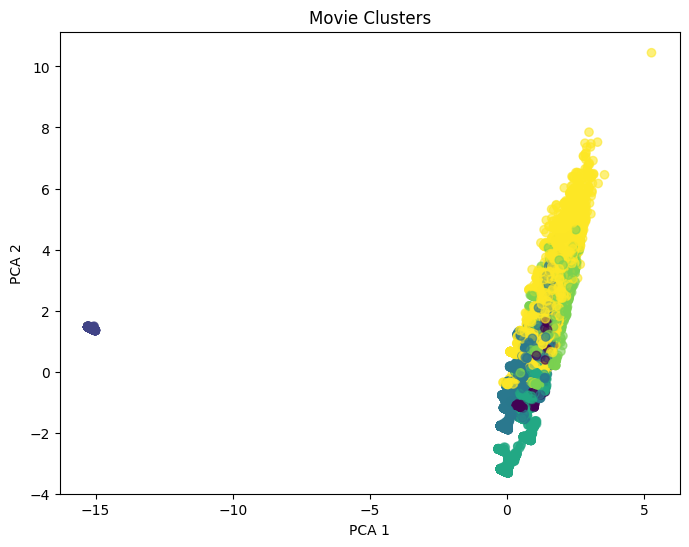

In [44]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

reduced = pca.fit_transform(X)

plt.figure(figsize=(8,6))

plt.scatter(
    reduced[:,0],
    reduced[:,1],
    c=movies['cluster'],
    cmap='viridis',
    alpha=0.6
)

plt.title("Movie Clusters")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.show()

In [45]:
for i in range(6):
    print("\nCluster", i)
    print(movies[movies['cluster']==i]['title'].head(10))


Cluster 0
76                            Nico Icon
97        Heidi Fleiss: Hollywood Madam
106                             Catwalk
114               Anne Frank Remembered
132                       Sonic Outlaws
134    From the Journals of Jean Seberg
159                               Crumb
189                            The Show
203                            Unzipped
242                         Hoop Dreams
Name: title, dtype: object

Cluster 1
55         Kids of the Round Table
83     Last Summer in the Hamptons
126                 Jupiter's Wife
137                         Target
390                   Desert Winds
398                   Dos Crímenes
401                   Federal Hill
554      The Beans of Egypt, Maine
595          A Great Day in Harlem
614                A Modern Affair
Name: title, dtype: object

Cluster 2
4                           Father of the Bride Part II
11                          Dracula: Dead and Loving It
17                                           Four R